In [1]:
import polars as pl
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
from pathlib import Path
from datetime import timedelta
import sys
sys.path.insert(0, "..")

from src.training.splits import make_backtest_folds
from src.training.dataset import prepare_fold, get_feature_cols, ID_COLS, TARGET, CAT_FEATURES
from src.training.metrics import compute_fold_weights_and_scales, calculate_sampled_wrmsse

FEATURES_DIR = Path("../data/processed/features")
MODELS_DIR = Path("../models")

plt.style.use("seaborn-v0_8-darkgrid")

In [2]:
model = lgb.Booster(model_file=str(MODELS_DIR / "lgbm_fold_3.txt"))

lf = pl.scan_parquet(FEATURES_DIR / "*.parquet")
dates = lf.select("date").collect()["date"].unique().sort().to_list()
folds = make_backtest_folds(dates)
fold3 = folds[2]

print(f"Fold 3: {fold3}")
print(f"Validation period: {fold3.val_start} to {fold3.val_end}")

Fold 3: Fold 3: train [2011-01-29 : 2016-03-27] gap 28d val [2016-04-25 : 2016-05-22]
Validation period: 2016-04-25 to 2016-05-22


In [3]:
from src.training.splits import get_fold_data

_, val_lf = get_fold_data(lf, fold3)
val_df = val_lf.collect()

feature_cols = get_feature_cols(val_df.columns)

STR_CAT_FEATURES = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]

with pl.StringCache():
    for col in STR_CAT_FEATURES:
        if col in val_df.columns:
            val_df = val_df.with_columns(
                pl.col(col).cast(pl.Categorical).to_physical().cast(pl.Int32)
            )

if "snap_wday_interaction" in val_df.columns:
    val_df = val_df.with_columns(
        pl.col("snap_wday_interaction").cast(pl.Int32)
    )

X_val = np.asarray(val_df.select(feature_cols).to_numpy(), dtype=np.float32)
y_val = val_df.select(TARGET).to_numpy().ravel()
val_ids = val_df.select("id").to_numpy().ravel()
val_dates = val_df.select("date").to_numpy().ravel()

y_pred = np.clip(model.predict(X_val), 0, None)

print(f"Val shape: {X_val.shape}")
print(f"Feature names (first 5): {feature_cols[:5]}")
print(f"Predictions range: [{y_pred.min():.3f}, {y_pred.max():.3f}]")
print(f"Actuals range: [{y_val.min():.3f}, {y_val.max():.3f}]")

Val shape: (853720, 63)
Feature names (first 5): ['wday', 'month', 'year', 'event_name_1', 'event_type_1']
Predictions range: [0.004, 169.471]
Actuals range: [0.000, 196.000]


In [4]:
def plot_series(
    series_id: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    ids: np.ndarray,
    dates: np.ndarray,
    title: str = None,
    ax=None,
):
    mask = ids == series_id
    s_dates = dates[mask]
    s_true = y_true[mask]
    s_pred = y_pred[mask]

    sort_idx = np.argsort(s_dates)
    s_dates = s_dates[sort_idx]
    s_true = s_true[sort_idx]
    s_pred = s_pred[sort_idx]

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    ax.bar(s_dates, s_true, alpha=0.6, label="Actual", color="steelblue", width=0.8)
    ax.plot(s_dates, s_pred, color="tomato", linewidth=2, label="Predicted", marker="o", markersize=4)
    ax.set_title(title or series_id, fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Units sold")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    rmse = np.sqrt(np.mean((s_true - s_pred) ** 2))
    mae = np.mean(np.abs(s_true - s_pred))
    
    # MAPE only where actuals > 0
    nonzero = s_true > 0
    if nonzero.sum() > 0:
        mape = np.mean(np.abs((s_true[nonzero] - s_pred[nonzero]) / s_true[nonzero])) * 100
        print(f"RMSE={rmse:.3f}  MAE={mae:.3f}  MAPE={mape:.1f}%")
        ax.set_title(f"{title or series_id}\nRMSE={rmse:.3f}  MAE={mae:.3f}  MAPE={mape:.1f}%", fontsize=11)
    else:
        print(f"RMSE={rmse:.3f}  MAE={mae:.3f}")
        ax.set_title(f"{title or series_id}\nRMSE={rmse:.3f}  MAE={mae:.3f}", fontsize=11)
    

    return ax

RMSE=14.765  MAE=11.462  MAPE=20.6%


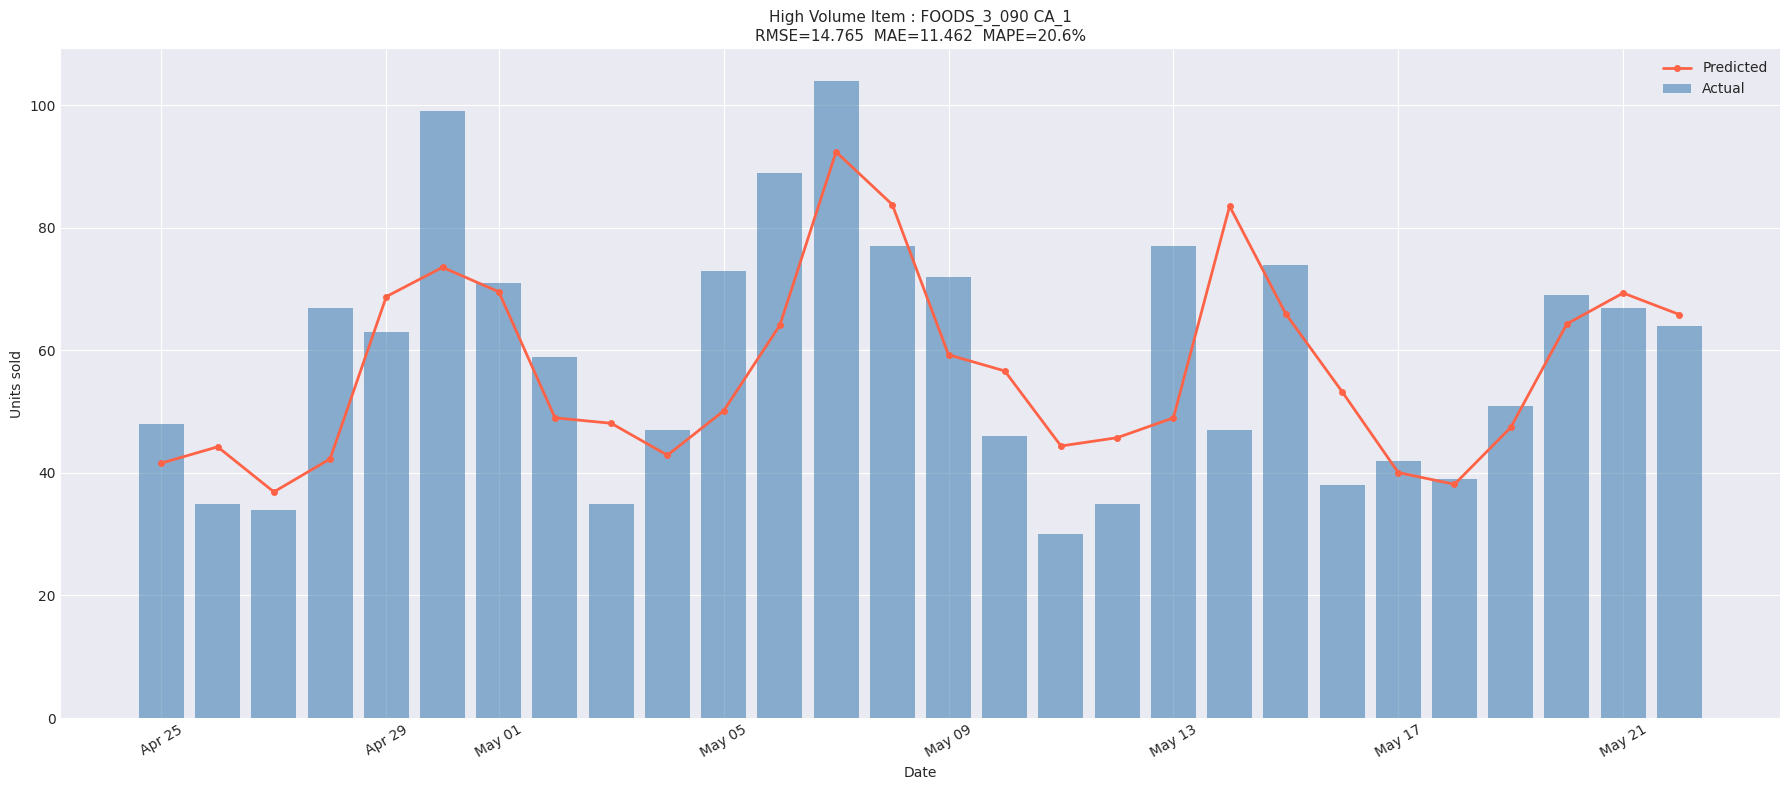

In [5]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_series(
    "FOODS_3_090_CA_1_evaluation",
    y_val, y_pred, val_ids, val_dates,
    title="High Volume Item : FOODS_3_090 CA_1",
    ax=ax,
)
plt.tight_layout()
plt.show()

RMSE=0.585  MAE=0.440  MAPE=76.3%


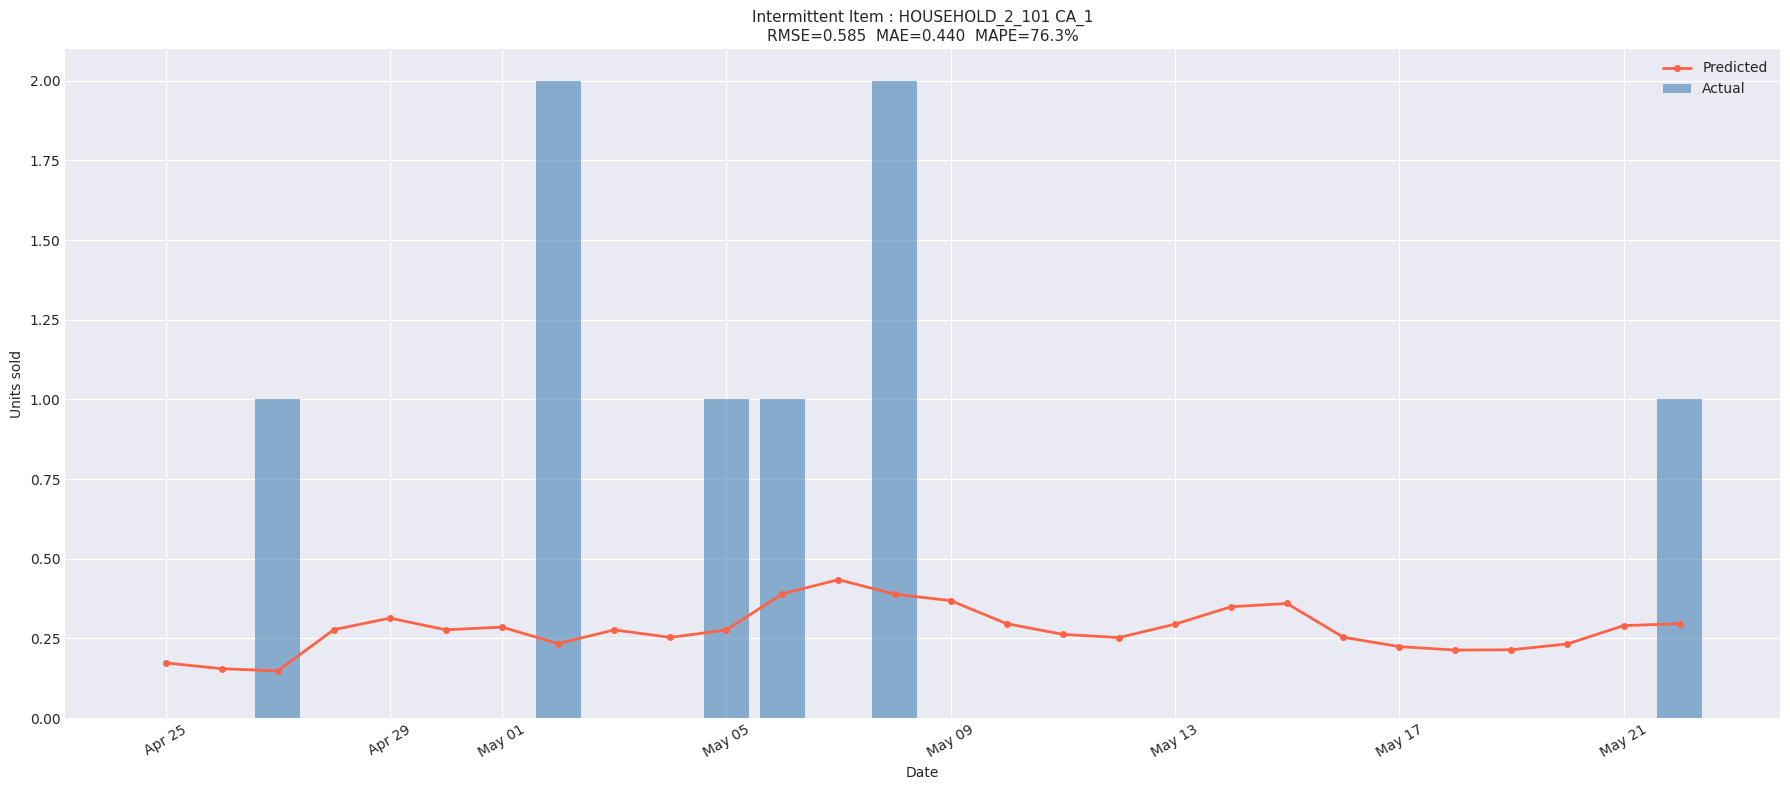

In [6]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_series(
    "HOUSEHOLD_2_101_CA_1_evaluation",
    y_val, y_pred, val_ids, val_dates,
    title="Intermittent Item : HOUSEHOLD_2_101 CA_1",
    ax=ax,
)
plt.tight_layout()
plt.show()

Mid-range item: FOODS_3_557_CA_3_evaluation
RMSE=3.088  MAE=2.470  MAPE=70.1%


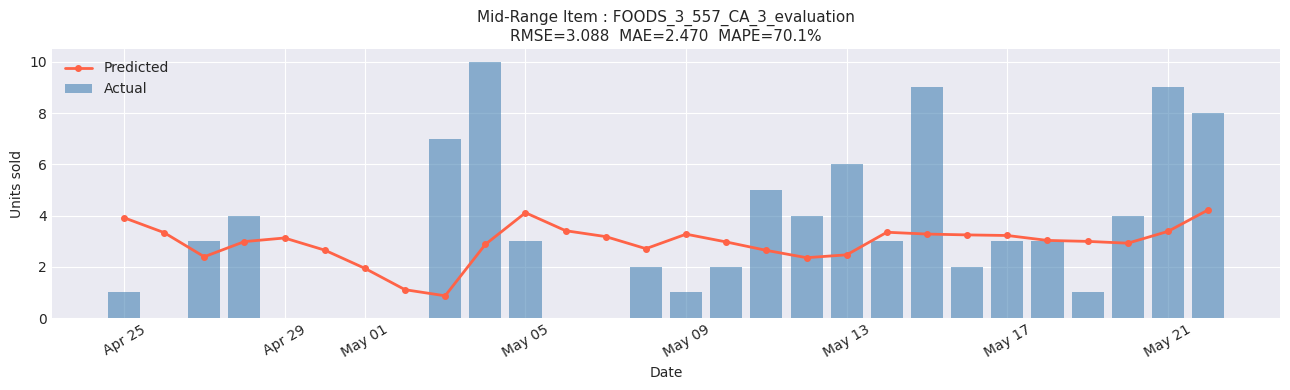

In [7]:
mid_items = (
    val_df.group_by("id")
    .agg(pl.col("sales").mean().alias("mean_sales"))
    .filter((pl.col("mean_sales") >= 2) & (pl.col("mean_sales") <= 10))
    .sort("mean_sales")
)

mid_item = mid_items[len(mid_items) // 2]["id"][0]
print(f"Mid-range item: {mid_item}")

fig, ax = plt.subplots(figsize=(13, 4))
plot_series(
    mid_item,
    y_val, y_pred, val_ids, val_dates,
    title=f"Mid-Range Item : {mid_item}",
    ax=ax,
)
plt.tight_layout()
plt.show()

Aggregated RMSE: 318.22  MAPE: 6.9%


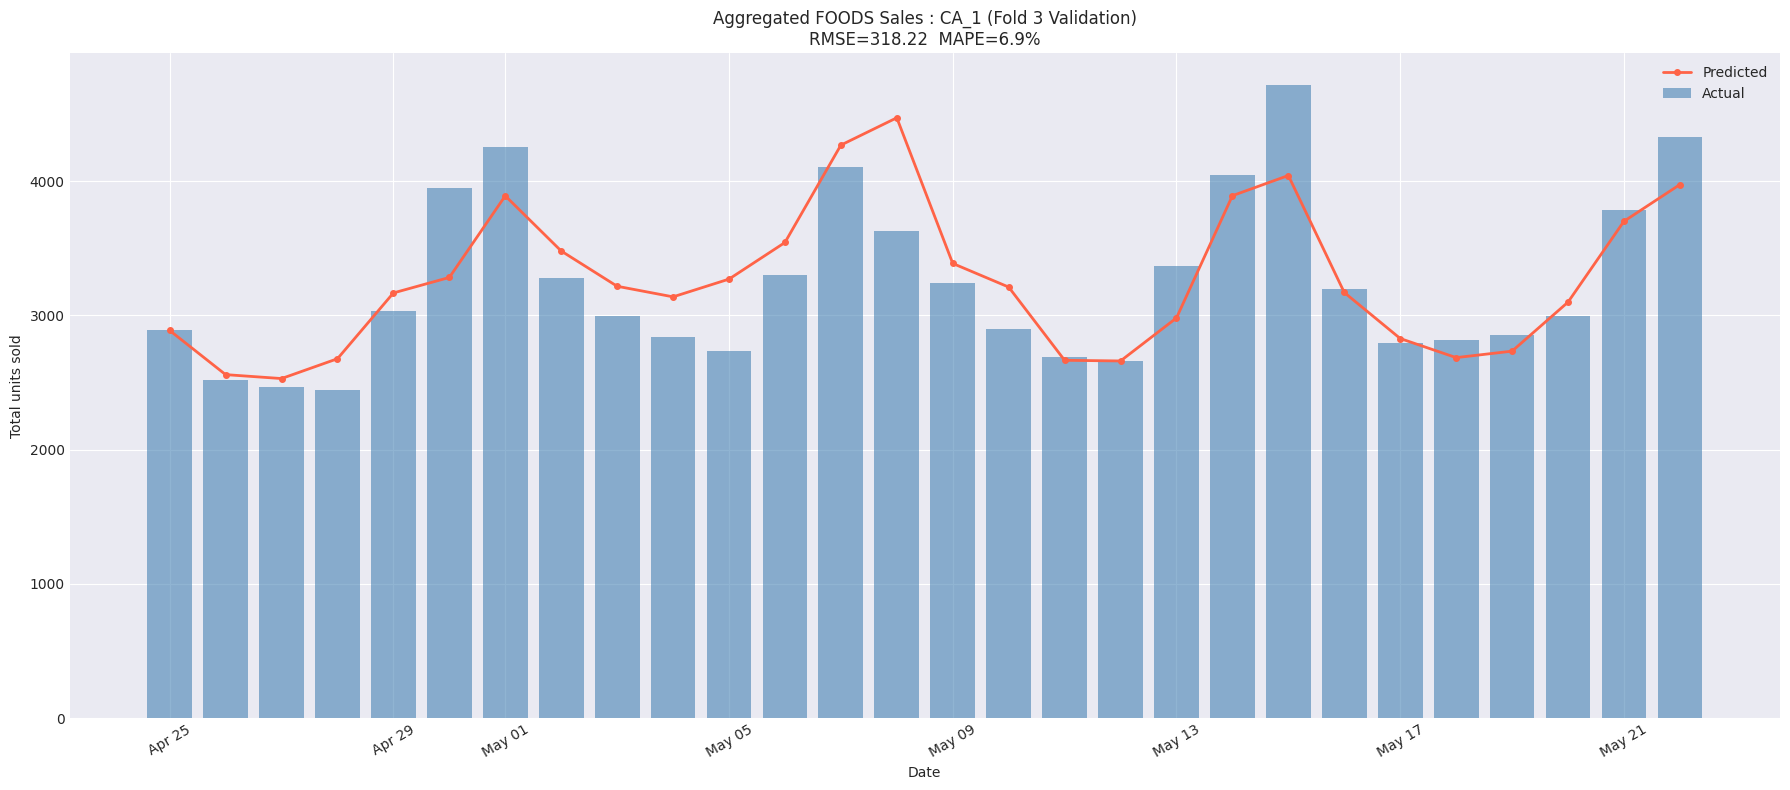

In [8]:
ca1_mask = np.array([id_.startswith("FOODS") and "CA_1" in id_ for id_ in val_ids])

ca1_dates = val_dates[ca1_mask]
ca1_true = y_val[ca1_mask]
ca1_pred = y_pred[ca1_mask]

unique_dates = np.unique(ca1_dates)
agg_true = np.array([ca1_true[ca1_dates == d].sum() for d in unique_dates])
agg_pred = np.array([ca1_pred[ca1_dates == d].sum() for d in unique_dates])

fig, ax = plt.subplots(figsize=(18, 8))
ax.bar(unique_dates, agg_true, alpha=0.6, label="Actual", color="steelblue", width=0.8)
ax.plot(unique_dates, agg_pred, color="tomato", linewidth=2,
        label="Predicted", marker="o", markersize=4)
ax.set_title("Aggregated FOODS Sales : CA_1 (Fold 3 Validation)")
ax.set_xlabel("Date")
ax.set_ylabel("Total units sold")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
rmse = np.sqrt(np.mean((agg_true - agg_pred) ** 2))
nonzero = agg_true > 0
mape = np.mean(np.abs((agg_true[nonzero] - agg_pred[nonzero]) / agg_true[nonzero])) * 100
print(f"Aggregated RMSE: {rmse:.2f}  MAPE: {mape:.1f}%")
ax.set_title(f"Aggregated FOODS Sales : CA_1 (Fold 3 Validation)\nRMSE={rmse:.2f}  MAPE={mape:.1f}%")
plt.tight_layout()
plt.show()

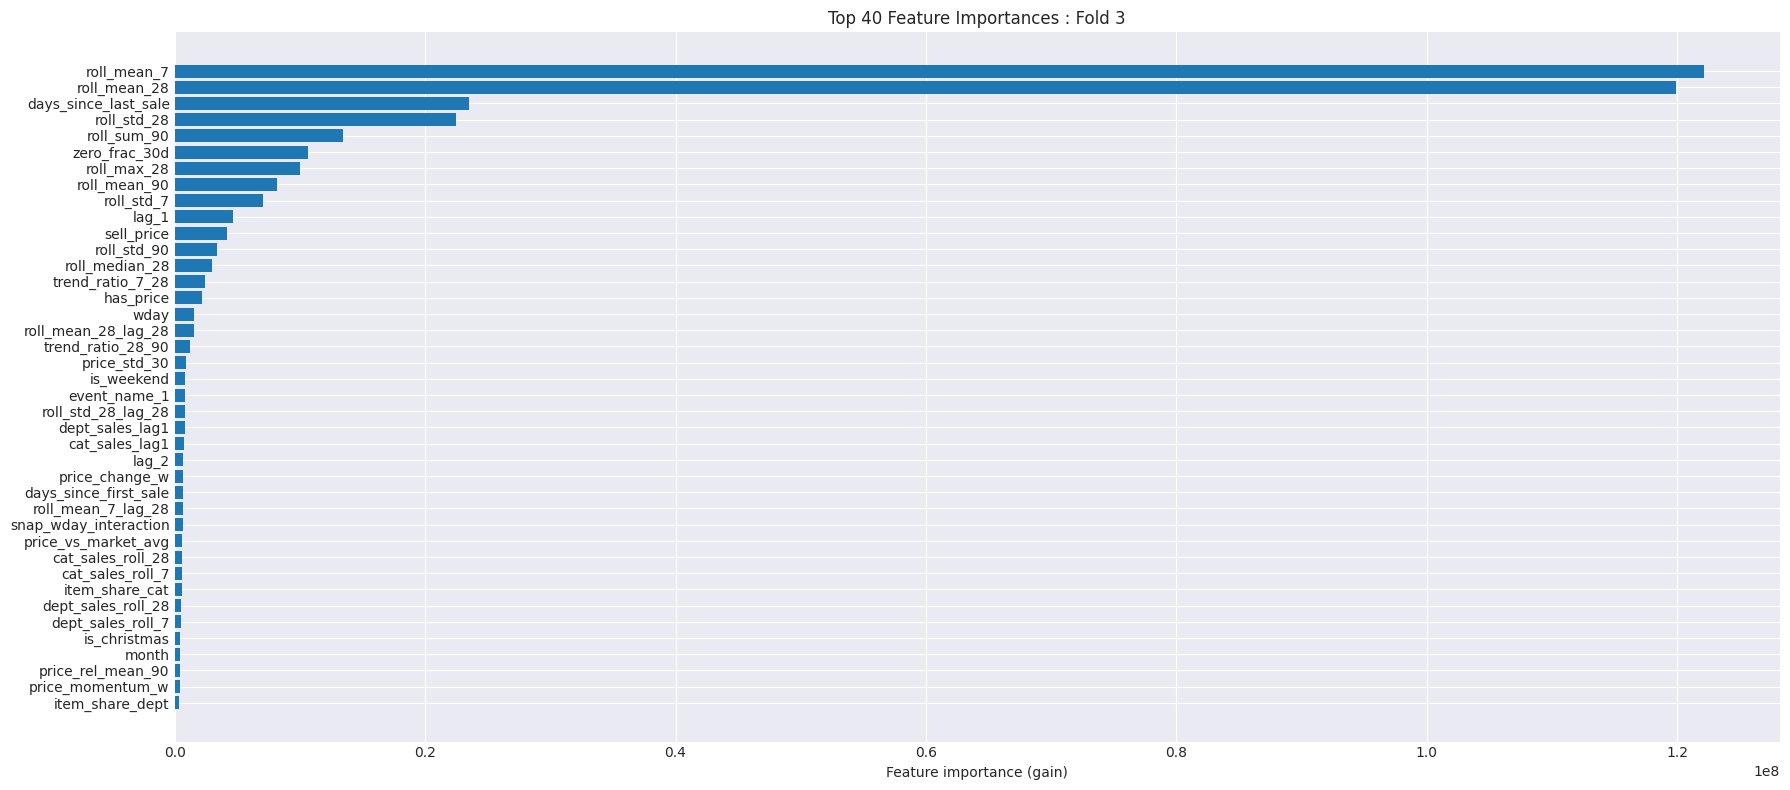

Rank Feature              Importance (Gain)
---------------------------------------------
1    roll_mean_7          122,092,975
2    roll_mean_28         119,924,063
3    days_since_last_sale 23,476,723
4    roll_std_28          22,486,368
5    roll_sum_90          13,431,719
6    zero_frac_30d        10,644,303
7    roll_max_28          10,019,799
8    roll_mean_90         8,186,242
9    roll_std_7           7,038,500
10   lag_1                4,639,869
11   sell_price           4,176,393
12   roll_std_90          3,346,129
13   roll_median_28       3,010,036
14   trend_ratio_7_28     2,395,202
15   has_price            2,149,576
16   wday                 1,583,900
17   roll_mean_28_lag_28  1,551,011
18   trend_ratio_28_90    1,249,465
19   price_std_30         929,415
20   is_weekend           839,337
21   event_name_1         836,789
22   roll_std_28_lag_28   796,663
23   dept_sales_lag1      790,773
24   cat_sales_lag1       719,336
25   lag_2                697,016
26   price_chan

In [9]:
importance = model.feature_importance(importance_type="gain")

feat_imp = sorted(
    zip(feature_cols, importance),
    key=lambda x: x[1],
    reverse=True
)[:40]
names, gains = zip(*feat_imp)

fig, ax = plt.subplots(figsize=(18, 8))
ax.barh(names[::-1], gains[::-1])
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Top 40 Feature Importances : Fold 3")
plt.tight_layout()
plt.show()

print(f"{'Rank':<4} {'Feature':<20} {'Importance (Gain)'}")
print("-" * 45)
for rank, (feat, gain) in enumerate(feat_imp[:40], 1):
    print(f"{rank:<4} {feat:<20} {gain:,.0f}")

In [18]:
# --- Summary ---
print("=" * 60)
print("FOLD 3 VALIDATION SUMMARY")
print("=" * 60)

print(f"\nValidation period: {fold3.val_start} to {fold3.val_end}")
print(f"Total series: {len(np.unique(val_ids)):,}")
print(f"Total predictions: {len(y_pred):,}")

print("\n--- Global Metrics ---")
global_rmse = np.sqrt(np.mean((y_val - y_pred) ** 2))
global_mae = np.mean(np.abs(y_val - y_pred))
nonzero = y_val > 0
global_mape = np.mean(np.abs((y_val[nonzero] - y_pred[nonzero]) / y_val[nonzero])) * 100
print(f"RMSE : {global_rmse:.4f}")
print(f"MAE  : {global_mae:.4f}")
print(f"MAPE : {global_mape:.1f}%")

print("\n--- CV Results (all folds) ---")
print("RMSE  : 1.9313 +- 0.0311")
print("MAE   : 0.9640")
print("WRMSSE : 0.7777")

print("\n--- Top 10 Features ---")
print(f"{'Rank':<6} {'Feature':<30} {'Importance (Gain)'}")
print("-" * 55)
for rank, (feat, gain) in enumerate(feat_imp[:10], 1):
    print(f"{rank:<6} {feat:<30} {gain:,.0f}")

print("\n--- Per-Series Metrics ---")
for label, sid in [
    ("High volume", "FOODS_3_090_CA_1_evaluation"),
    ("Intermittent", "HOUSEHOLD_2_101_CA_1_evaluation"),
    ("Mid-range", mid_item),
]:
    mask = val_ids == sid
    s_true = y_val[mask]
    s_pred = y_pred[mask]
    rmse = np.sqrt(np.mean((s_true - s_pred) ** 2))
    mae = np.mean(np.abs(s_true - s_pred))
    nz = s_true > 0
    mape = np.mean(np.abs((s_true[nz] - s_pred[nz]) / s_true[nz])) * 100 if nz.sum() > 0 else float("nan")
    print(f"{label:<15} {sid:<45} RMSE={rmse:.3f}  MAE={mae:.3f}  MAPE={mape:.1f}%")

FOLD 3 VALIDATION SUMMARY

Validation period: 2016-04-25 to 2016-05-22
Total series: 30,490
Total predictions: 853,720

--- Global Metrics ---
RMSE : 1.9354
MAE  : 0.9929
MAPE : 55.3%

--- CV Results (all folds) ---
RMSE  : 1.9313 +- 0.0311
MAE   : 0.9640
WRMSSE : 0.7777

--- Top 10 Features ---
Rank   Feature                        Importance (Gain)
-------------------------------------------------------
1      roll_mean_7                    122,092,975
2      roll_mean_28                   119,924,063
3      days_since_last_sale           23,476,723
4      roll_std_28                    22,486,368
5      roll_sum_90                    13,431,719
6      zero_frac_30d                  10,644,303
7      roll_max_28                    10,019,799
8      roll_mean_90                   8,186,242
9      roll_std_7                     7,038,500
10     lag_1                          4,639,869

--- Per-Series Metrics ---
High volume     FOODS_3_090_CA_1_evaluation                   RMSE=14.765 

In [19]:
lf = pl.scan_parquet("../data/processed/features/*.parquet")
print(lf.select(pl.col("date").max()).collect())

shape: (1, 1)
┌────────────┐
│ date       │
│ ---        │
│ date       │
╞════════════╡
│ 2016-05-22 │
└────────────┘


In [20]:
dates = (
        lf.select("date")
        .collect()["date"]
        .unique()
        .sort()
        .to_list()
    )

folds = make_backtest_folds(dates)

In [21]:
from datetime import date

df_weight_ref = pl.scan_parquet(FEATURES_DIR / "*.parquet").select(
    ["id", "date", "sales", "sell_price"]
).collect()

fold3 = folds[2]
m5_ref_fold3 = compute_fold_weights_and_scales(df_weight_ref, fold3.train_end)

val_groups = {}
for idx, sid in enumerate(val_ids):
    val_groups.setdefault(sid, []).append(idx)

random.seed(42)
sample_ids = random.sample(list(val_groups.keys()), 10)

print(f"{'ID':<45} {'RMSE':>8} {'scale':>10} {'sqrt(scale)':>12} {'RMSSE':>8} {'weight':>12}")
print("-" * 100)
for sid in sample_ids:
    ref = m5_ref_fold3.get(sid)
    if ref is None:
        continue
    idx = val_groups[sid]
    rmse = np.sqrt(np.mean((y_val[idx] - y_pred[idx])**2))
    rmsse = rmse / np.sqrt(ref["scale"])
    print(f"{sid:<45} {rmse:>8.4f} {ref['scale']:>10.4f} {np.sqrt(ref['scale']):>12.4f} {rmsse:>8.4f} {ref['weight']:>12.8f}")

ID                                                RMSE      scale  sqrt(scale)    RMSSE       weight
----------------------------------------------------------------------------------------------------
HOUSEHOLD_2_125_TX_3_evaluation                 0.3915     0.1435       0.3788   1.0336   0.00000000
FOODS_2_385_CA_2_evaluation                     1.8389     4.3993       2.0974   0.8767   0.00002597
FOODS_3_207_CA_1_evaluation                     1.9337    12.8349       3.5826   0.5398   0.00001134
HOUSEHOLD_2_424_WI_1_evaluation                 0.6728     0.5723       0.7565   0.8894   0.00000629
HOUSEHOLD_2_382_CA_3_evaluation                 1.5743     2.0207       1.4215   1.1075   0.00001804
HOBBIES_2_074_CA_3_evaluation                   0.5905     0.3559       0.5966   0.9897   0.00000542
FOODS_3_604_CA_3_evaluation                     2.0776    11.9859       3.4621   0.6001   0.00004322
HOBBIES_1_089_CA_2_evaluation                   1.3469     2.2571       1.5024   0.8966   0

## Fold 3 Validation Summary

**Validation period:** 2016-04-25 to 2016-05-22 | **Series:** 30,490 | **Predictions:** 853,720

### Global Metrics
| Metric | Fold 3 | CV Mean (all folds) |
|--------|--------|---------------------|
| RMSE | 1.9354 | 1.9313 +- 0.0311 |
| MAE | 0.9929 | 0.9640 |
| MAPE | 55.3% | x |
| WRMSSE | x | 0.7777 |

### Per-Series Performance
| Type | Item ID | RMSE | MAE | MAPE |
|------|---------|------|-----|------|
| High volume | FOODS_3_090_CA_1_evaluation | 14.765 | 11.462 | 20.6% |
| Intermittent | HOUSEHOLD_2_101_CA_1_evaluation | 0.585 | 0.440 | 76.3% |
| Mid-range | FOODS_3_557_CA_3_evaluation | 3.088 | 2.470 | 70.1% |
| Aggregate | Foods (Department Level) | 318.22 | X | 6.9% |

> **Data Performance Note:** High-volume series demonstrate strong scale stability with a 20.6% MAPE, indicating that the model captures consistent consumer demand patterns effectively. Intermittent and mid-range series carry higher percentage penalties (76.3% and 70.1% MAPE, respectively) primarily due to low-integer target bounds where minor unit deviations result in sharp percentage fluctuations. Highly aggregated departmental predictions remain exceptionally clean at a 6.9% MAPE, confirming that individual item errors successfully cancel out under hierarchical summation.

### Top 10 Features by Gain
| Rank | Feature | Importance (Gain) | Notes |
|------|---------|-------------------|-------|
| 1 | roll_mean_7 | 122,092,975 | Short-term historical baseline window |
| 2 | roll_mean_28 | 119,924,063 | Medium-term trend context |
| 3 | days_since_last_sale | 23,476,723 | Critical sparse-demand intermittent indicator |
| 4 | roll_std_28 | 22,486,368 | Medium-term demand variance scale |
| 5 | roll_sum_90 | 13,431,719 | Long-horizon historical volume tracking |
| 6 | zero_frac_30d | 10,644,303 | Captures zero-inflation and item inactivity |
| 7 | roll_max_28 | 10,019,799 | Upper boundary demand capacity |
| 8 | roll_mean_90 | 8,186,242 | Macro seasonal trajectory trend |
| 9 | roll_std_7 | 7,038,500 | Short-term volatility and weekday noise flag |
| 10 | lag_1 | 4,639,869 | Direct yesterday-sales baseline anchor |

> **Feature Interaction Insight:** The clear dominance of `roll_mean_7` and `roll_mean_28` demonstrates that recent demand history forms the primary signal for the LightGBM tree structures. For intermittent demand profiles, the presence of `days_since_last_sale` and `zero_frac_30d` in the top tiers indicates that the Tweedie objective effectively utilizes sparsity tracking to calibrate its zero-inflation boundaries.

### Model Configuration
- **Architecture:** Symmetrical Global LightGBM (`num_leaves=255`, `min_data_in_leaf=255`)
- **Objective:** Tweedie Regression (`tweedie_variance_power=1.1`, evaluated on `metric='rmse'`)
- **Sample Weighting:** Robust median-normalized WRMSSE weighting applied exclusively to `dtrain` (`clip(0.2, 5.0)`)
- **Validation:** 3-fold rolling-origin backtest, unweighted `dval` monitoring, 28-day gap
- **Post-Processing:** Multi-seed ensemble averaging with post-hoc Powell department optimization bounds `[(0.80, 1.20)]`